In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
train = pd.read_csv("../data/letters_train_fixed.csv", header=None)

y_train = train[0]
X_train = train.drop(0, axis=1)

print(X_train.shape, y_train.shape)

(88800, 784) (88800,)


In [3]:
X = X_train.values.reshape(-1, 1, 28, 28) / 255.0
y = y_train.values - 1

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 26)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = CNN()

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    total_loss = 0

    for xb, yb in loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 789.2768
Epoch 2, Loss: 378.9748
Epoch 3, Loss: 307.3545
Epoch 4, Loss: 266.0233
Epoch 5, Loss: 231.5790


In [6]:
with torch.no_grad():
    outputs = model(X)
    preds = torch.argmax(outputs, dim=1)
    acc = (preds == y).float().mean()

print("Accuracy:", acc.item())

Accuracy: 0.9503152966499329


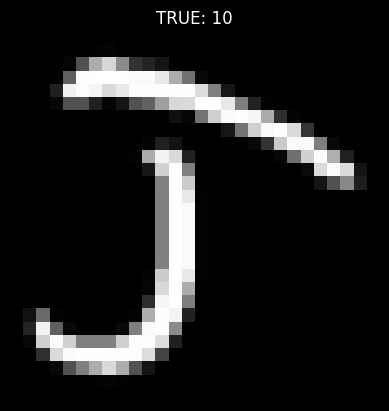

PRED: 10


In [7]:
i = 10

img = X[i].numpy().reshape(28, 28)

plt.imshow(img, cmap="gray")
plt.title(f"TRUE: {y_train.iloc[i]}")
plt.axis("off")
plt.show()

with torch.no_grad():
    pred = torch.argmax(model(X[i].unsqueeze(0))).item()

print("PRED:", pred + 1)

In [8]:
torch.save(model.state_dict(), "../model/cnn.pth")

In [9]:
import torch
import numpy as np

model.eval()

with torch.no_grad():
    outputs = model(X)  # X = (n, 1, 28, 28)
    preds = torch.argmax(outputs, dim=1).cpu().numpy()

y_true = y.cpu().numpy()

In [10]:
from sklearn.metrics import classification_report

letters = [chr(65 + i) for i in range(26)]

print(classification_report(y_true, preds, target_names=letters))

              precision    recall  f1-score   support

           A       0.94      0.97      0.96      3396
           B       0.99      0.97      0.98      3396
           C       0.97      0.99      0.98      3419
           D       0.97      0.98      0.97      3398
           E       0.99      0.97      0.98      3437
           F       0.98      0.97      0.98      3394
           G       0.83      0.92      0.87      3385
           H       0.98      0.97      0.97      3424
           I       0.73      0.84      0.78      3428
           J       0.95      0.97      0.96      3402
           K       0.99      0.98      0.98      3438
           L       0.82      0.69      0.75      3415
           M       1.00      0.99      0.99      3402
           N       0.95      0.99      0.97      3365
           O       0.98      0.98      0.98      3408
           P       0.99      0.98      0.99      3430
           Q       0.93      0.82      0.87      3435
           R       0.96    

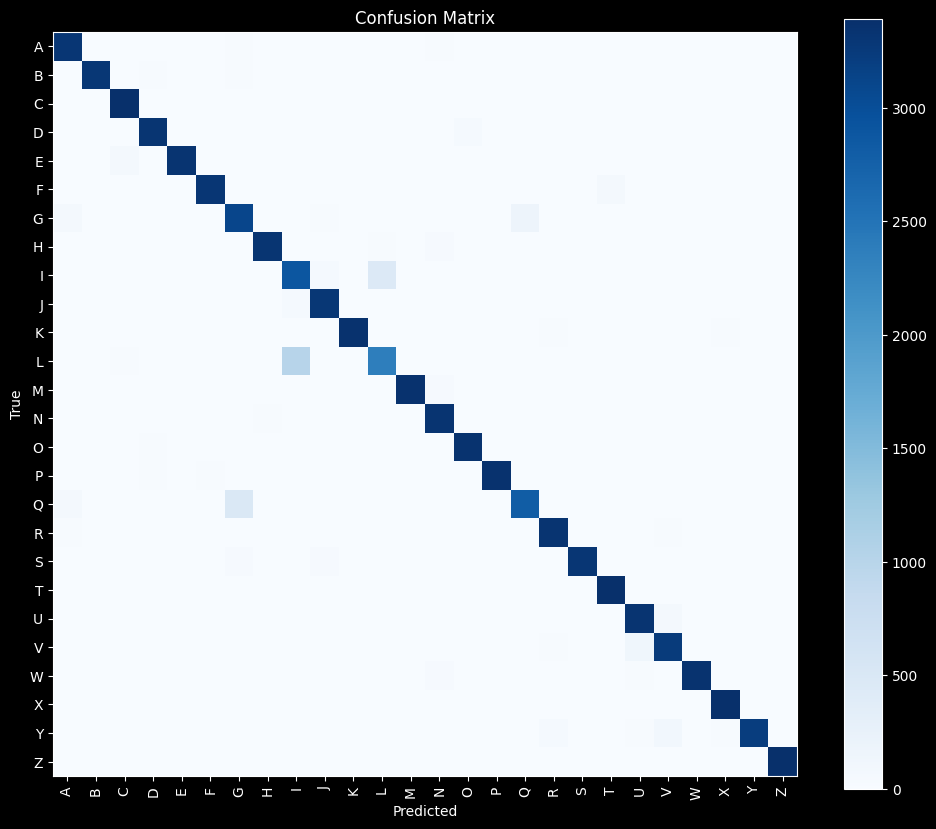

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(26), letters, rotation=90)
plt.yticks(range(26), letters)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

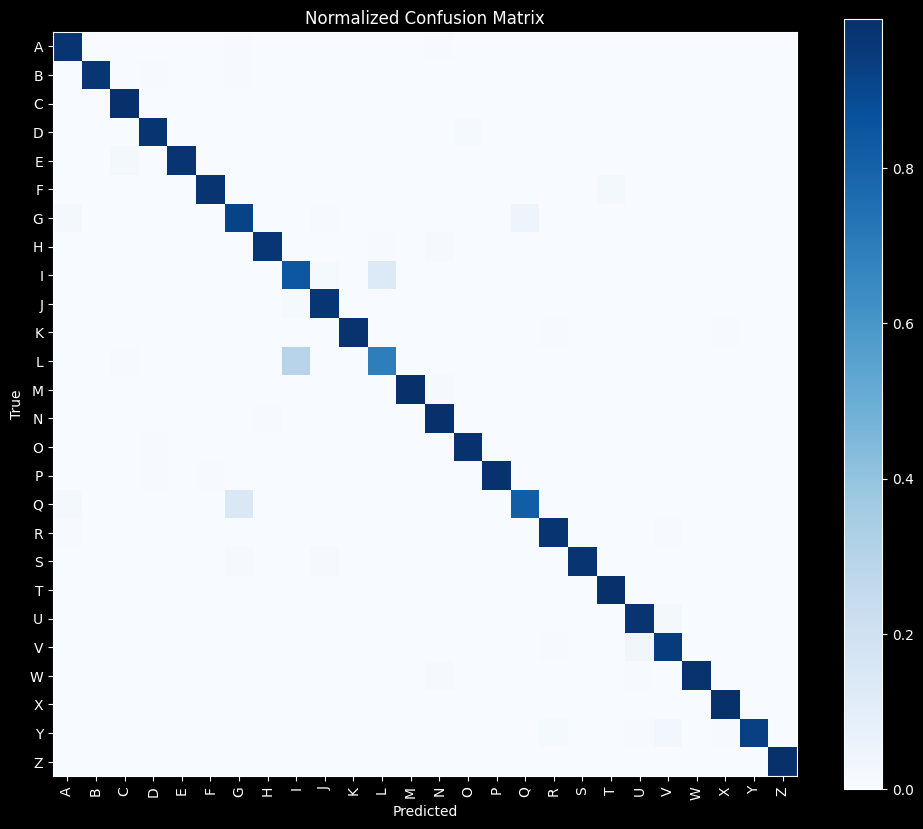

In [12]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, cmap="Blues")
plt.colorbar()

plt.xticks(range(26), letters, rotation=90)
plt.yticks(range(26), letters)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [13]:
errors = []

for i in range(len(y_true)):
    if y_true[i] != preds[i]:
        errors.append((y_true[i], preds[i]))

from collections import Counter

top_errors = Counter(errors).most_common(10)

for (true, pred), count in top_errors:
    print(f"{letters[true]} → {letters[pred]}: {count}")

L → I: 996
Q → G: 500
I → L: 463
G → Q: 159
V → U: 124
Y → V: 101
Q → A: 79
E → C: 69
U → V: 68
G → A: 60
